# Model Evaluation Pipeline

This notebook evaluates multiple machine learning models for the Job Shortlisting Prediction Model.
It loads the dataset, trains several models (Decision Tree, Linear Regression, Random Forest, SVR, Gradient Boosting),
and compares their performance using MSE and R2 metrics. It also visualizes the results.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import numpy as np
from sklearn.model_selection import train_test_split

# Add current directory to path to import training modules
sys.path.append(os.getcwd())

# Import training modules
import decisionTreeTraining
import linearRegressionTraining
import randomForestTraining
import svrTraining
import gradientBoostingTraining


In [5]:
# Load dataset
try:
    df = decisionTreeTraining.load_dataset()
except FileNotFoundError:
    print("Dataset not found with default path. Trying adjusted path...")
    # Adjust path if running from pipeline directory or root
    if os.path.exists("data/processed/feature_extracted_dataset.csv"):
        df = decisionTreeTraining.load_dataset("data/processed/feature_extracted_dataset.csv")
    elif os.path.exists("../data/processed/feature_extracted_dataset.csv"):
        df = decisionTreeTraining.load_dataset("../data/processed/feature_extracted_dataset.csv")
    else:
        raise FileNotFoundError("Could not find dataset.")

print(f"Dataset loaded: {df.shape}")
df.head()

Dataset loaded: (10000, 13)


,candidate_id,job_id,role,candidate_skills_list,recruiter_priority_list,recruiter_skill_weights_dict,experience_years,candidate_skill_count,recruiter_skill_count,weighted_match_sum,total_recruiter_weight,weighted_match_ratio,label_score
0,c103,j180,financial analyst,"['sales', 'support', 'docker', 'seo', 'c', 'no...","['seo', 'sales', 'prototyping', 'git']","{'seo': 5, 'sales': 4, 'prototyping': 3, 'git'...",11,8,4,11,14,0.785714,3.52
1,c200,j190,devops engineer,"['ml', 'node', 'java', 'git', 'python', 'netwo...","['git', 'java', 'cloud', 'node', 'networking',...","{'git': 5, 'java': 4, 'cloud': 3, 'node': 2, '...",6,6,6,13,16,0.812500,3.27
2,c187,j086,hr coordinator,"['sql', 'excel', 'figma']","['git', 'docker', 'prototyping']","{'git': 5, 'docker': 4, 'prototyping': 3}",0,3,3,0,12,0.000000,1.00
3,c093,j003,product manager,"['git', 'embedded']","['embedded', 'crm', 'git', 'excel', 'docker']","{'embedded': 5, 'crm': 4, 'git': 3, 'excel': 2...",7,2,5,8,15,0.533333,2.53
4,c116,j075,software engineer,"['ml', 'teamwork', 'support', 'firewall']","['excel', 'teamwork', 'ml', 'support', 'firewa...","{'excel': 5, 'teamwork': 4, 'ml': 3, 'support'...",12,4,5,10,15,0.666667,3.53


In [6]:
# Train models and collect results
results = {}
models_modules = {
    "Decision Tree": decisionTreeTraining,
    "Linear Regression": linearRegressionTraining,
    "Random Forest": randomForestTraining,
    "SVR": svrTraining,
    "Gradient Boosting": gradientBoostingTraining
}

# We need to reproduce the test set to visualize predictions later
feature_cols = [
    "candidate_skill_count",
    "recruiter_skill_count",
    "weighted_match_sum",
    "total_recruiter_weight",
    "weighted_match_ratio",
    "experience_years"
]

X = df[feature_cols]
y = df["label_score"]

# Train-Test Split (10% test) - using same seed as training scripts
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

for name, module in models_modules.items():
    print(f"Training {name}...")
    # The train_model function handles splitting and training internally, 
    # but uses the same random_state=42, so the model is trained on the same X_train we defined implicitly.
    results[name] = module.train_model(df)

Training Decision Tree...
Preparing features...
Starting GridSearchCV (5-fold cross-validation) ...
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best Hyperparameters: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV Score (MSE): 0.3199682623109621

Evaluating on Test Set...
Test MSE: 0.33054400370081854
Test R² : 0.8269440699223053

Model saved to: models/best_decision_tree_model.joblib
Training Linear Regression...
Preparing features for Linear Regression (Ridge)...
Starting GridSearchCV...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Hyperparameters: {'regressor__alpha': 0.1}
Best CV Score (MSE): 0.31627054230856716

Evaluating on Test Set...
Test MSE: 0.32762866281469316
Test R² : 0.8284703932647145

Model saved to: models/best_linear_regression_model.joblib
Training Random Forest...
Preparing features for Random Forest...
Starting GridSearchCV...
Fitting 5 folds for each of 36 candidates, to

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25132\2792704466.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="MSE", data=metrics_df, palette="viridis")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_25132\2792704466.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="R2", data=metrics_df, palette="magma")


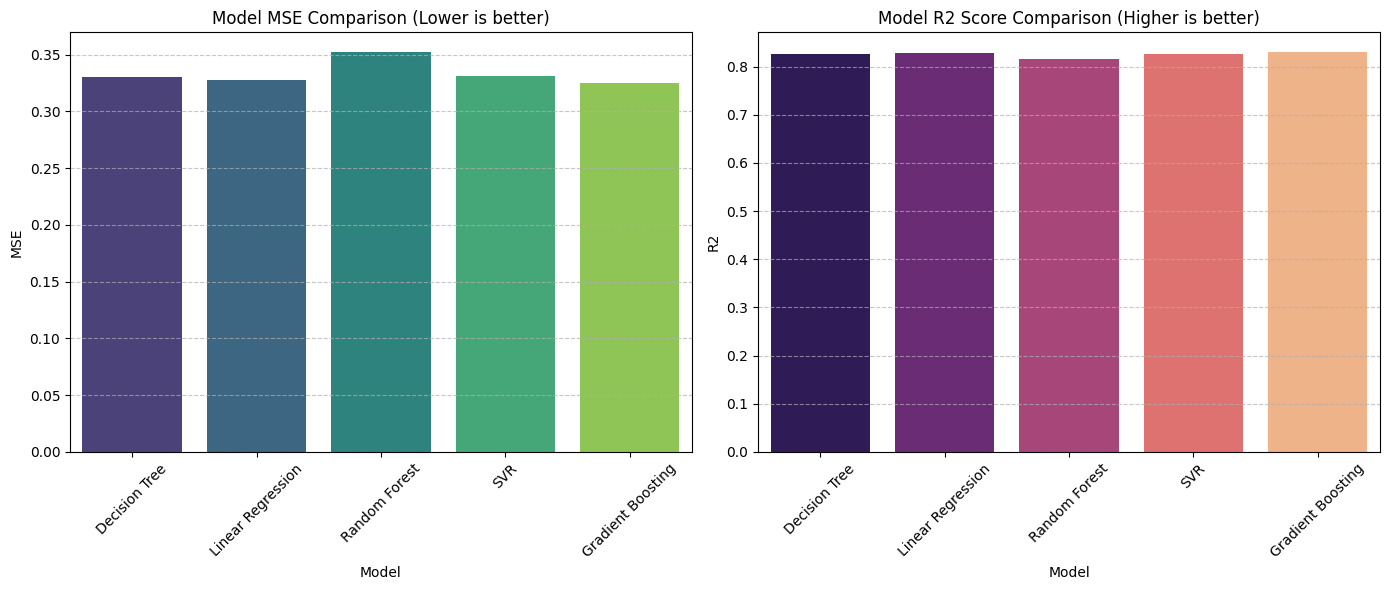

               Model       MSE        R2
0      Decision Tree  0.330544  0.826944
1  Linear Regression  0.327629  0.828470
2      Random Forest  0.352023  0.815699
3                SVR  0.331528  0.826429
4  Gradient Boosting  0.325294  0.829693


In [7]:
# Compare Metrics
metrics_data = {
    "Model": [],
    "MSE": [],
    "R2": []
}

for name, res in results.items():
    metrics_data["Model"].append(name)
    metrics_data["MSE"].append(res["mse"])
    metrics_data["R2"].append(res["r2"])

metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x="Model", y="MSE", data=metrics_df, palette="viridis")
plt.title("Model MSE Comparison (Lower is better)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.barplot(x="Model", y="R2", data=metrics_df, palette="magma")
plt.title("Model R2 Score Comparison (Higher is better)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(metrics_df)

In [ ]:
# Predicted vs Actual Plots
plt.figure(figsize=(15, 12))

for i, (name, res) in enumerate(results.items()):
    model = res["model"]
    
    # Predict on our X_test
    y_pred = model.predict(X_test)
    
    plt.subplot(2, 3, i+1)
    plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name} (R2: {res['r2']:.2f})")
    plt.grid(True)

plt.tight_layout()
plt.show()